<a href="https://colab.research.google.com/github/teemaphorn/delivery-project/blob/main/Project_Parcel_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###ส่วนรับเข้าพัสดุทีละชิ้น

In [ ]:
import random
import pandas as pd

# 1. ประกาศ Class สำหรับเก็บข้อมูลองค์ประกอบต่างๆ

class Customer:
    # เก็บข้อมูลลูกค้า (ผู้ส่ง/ผู้รับ)
    def __init__(self, customer_id, name, phone):
        self.customer_id = customer_id
        self.name = name
        self.phone = phone

class Parcel:
    # เก็บข้อมูลพัสดุและกำหนดประเภทบริการเริ่มต้น
    def __init__(self, parcel_id, weight_kg, service_type="ธรรมดา"):
        self.parcel_id = parcel_id
        self.weight_kg = weight_kg
        self.service_type = service_type

class ParcelIntake:
    # รวมข้อมูลการรับพัสดุ 1 รายการ
    def __init__(self, intake_id, sender_obj, recipient_obj, parcel_obj, distance_km):
        self.intake_id = intake_id
        self.sender = sender_obj
        self.recipient = recipient_obj
        self.parcel = parcel_obj
        self.distance_km = distance_km
        self.status = "รับแล้ว"

    def get_summary(self):
        # แปลงเป็น dict เพื่อเตรียมเอาไปสร้าง DataFrame
        return {
            "intake_id": self.intake_id,
            "parcel_id": self.parcel.parcel_id,
            "sender_name": self.sender.name,
            "recipient_name": self.recipient.name,
            "weight_kg": self.parcel.weight_kg,
            "service_type": self.parcel.service_type,
            "distance_km": self.distance_km,
            "status": self.status
        }


# 2. ฟังก์ชันช่วยสุ่มข้อมูลตัวอย่าง

def generate_customer_name():
    # สุ่มชื่อ-นามสกุล
    first_names = ["เรยา", "มุนินทร์", "มุตตา", "เรณู", "พิไล", "ทองดี"]
    last_names = ["วงศ์เสวต", "จงสวัสดิ์", "จงสวัสดิ์", "ตาคลี", "อัศวรุ่งเรืองกิจ", "บุญพูลทรัพย์ "]
    return f"{random.choice(first_names)} {random.choice(last_names)}"

def generate_random_weight(min_w=0.5, max_w=15.0):
    # สุ่มน้ำหนักพัสดุ (ทศนิยม 2 ตำแหน่ง)
    return round(random.uniform(min_w, max_w), 2)

def generate_random_distance(min_d=1.0, max_d=250.0):
    # สุ่มระยะทาง (ทศนิยม 1 ตำแหน่ง)
    return round(random.uniform(min_d, max_d), 1)


# 3. ส่วนสร้างข้อมูล 300 รายการและบันทึกไฟล์

random.seed(42)  # ล็อกค่า random ให้ผลลัพธ์คงที่
intake_records = []
service_options = ["ธรรมดา", "ด่วนพิเศษ (Express)", "แช่เย็น (Cold Chain)"]

# วนลูปสร้างออเดอร์ 300 รายการ
for i in range(1, 301):
    sender = Customer(f"CUS-S{i:03d}", generate_customer_name(), f"08{random.randint(10000000, 99999999)}")
    recipient = Customer(f"CUS-R{i:03d}", generate_customer_name(), f"09{random.randint(10000000, 99999999)}")

    parcel_item = Parcel(
        parcel_id=f"TH{i:05d}",
        weight_kg=generate_random_weight(),
        service_type=random.choice(service_options)
    )

    intake_item = ParcelIntake(
        intake_id=f"INT-{i:04d}",
        sender_obj=sender,
        recipient_obj=recipient,
        parcel_obj=parcel_item,
        distance_km=generate_random_distance()
    )

    intake_records.append(intake_item.get_summary())

# แปลงเป็น DataFrame และเซฟลง CSV
df_intake = pd.DataFrame(intake_records)
df_intake.to_csv("parcel_intake_300.csv", index=False, encoding="utf-8-sig")

print(f"การรับพัสดุเข้าระบบสำเร็จทั้งหมด")
df_intake.head()

การรับพัสดุเข้าระบบสำเร็จทั้งหมด


,intake_id,parcel_id,sender_name,recipient_name,weight_kg,service_type,distance_km,status
0,INT-0001,TH00001,ทองดี วงศ์เสวต,ทองดี จงสวัสดิ์,3.74,แช่เย็น (Cold Chain),26.5,รับแล้ว
1,INT-0002,TH00002,ทองดี อัศวรุ่งเรืองกิจ,พิไล ตาคลี,0.93,ธรรมดา,58.9,รับแล้ว
2,INT-0003,TH00003,พิไล วงศ์เสวต,มุนินทร์ บุญพูลทรัพย์,10.67,ด่วนพิเศษ (Express),55.9,รับแล้ว
3,INT-0004,TH00004,พิไล จงสวัสดิ์,มุนินทร์ บุญพูลทรัพย์,5.43,ธรรมดา,54.6,รับแล้ว
4,INT-0005,TH00005,มุตตา วงศ์เสวต,เรณู วงศ์เสวต,12.79,แช่เย็น (Cold Chain),66.9,รับแล้ว


In [ ]:
import random
import pandas as pd

def calculate_shipping_fee(weight_kg, distance_km, service_type="ธรรมดา"):
    """
    ฟังก์ชันคำนวณค่าจัดส่งพัสดุ
    - weight_kg: น้ำหนักพัสดุ (กิโลเมตร)
    - distance_km: ระยะทางจัดส่ง (กิโลเมตร)
    - service_type: ประเภทบริการ (มี Default Value เป็น 'ธรรมดา')
    """
    base_fee = 15  # ค่าเปิดบิล(บาท)

# 1. คำนวณค่าบริการตามน้ำหนัก
    if weight_kg <= 1.0:
        weight_fee = 10                         # ไม่เกิน 1 kg คิด 10 บาท
    elif weight_kg <= 5.0:
        weight_fee = 10 + ((weight_kg - 1.0) * 5) # เกิน 1kg คิดเพิ่มkgละ5บาท
    else:
        weight_fee = 30 + ((weight_kg - 5.0) * 8) # เกิน 5 kg คิดเพิ่มkgละ8บาท

# 2. คำนวณค่าระยะทางแบบแบ่งโซน (Zone-based)

    if distance_km <= 15:
        distance_fee = 5    # ในเมือง/พื้นที่ใกล้เคียง
    elif distance_km <= 50:
        distance_fee = 15   # ข้ามอำเภอ/จังหวัดใกล้ๆ
    elif distance_km <= 150:
        distance_fee = 30   # ข้ามจังหวัดระยะกลาง
    else:
        distance_fee = 50   # ส่งข้ามภูมิภาค/ไกลมาก

 # 3. ตัวคูณตามประเภทบริการ (Multiplier)
    service_multipliers = {
        "ธรรมดา": 1.0,
        "ด่วนพิเศษ": 1.4,   # เพิ่มขึ้น 40%
        "แช่เย็น": 1.6   # เพิ่มขึ้น 60%
    }

    multiplier = service_multipliers.get(service_type, 1.0)

# รวมราคาทั้งหมด
    total_fee = (base_fee + weight_fee + distance_fee) * multiplier
    return round(total_fee, 2)

df_intake["shipping_fee"] = df_intake.apply(
    lambda row: calculate_shipping_fee(
        row["weight_kg"],
        row["distance_km"],
        row["service_type"]
    ),
    axis=1
)

from IPython.display import display

print("การคำนวณค่าจัดส่งตามน้ำหนัก/ระยะทางทั้งหมด 300 รายการเสร็จสมบูรณ์แล้ว")

with pd.option_context("display.max_rows", None):
    display(df_intake[["intake_id", "parcel_id", "sender_name", "recipient_name",
                        "weight_kg", "distance_km", "service_type", "shipping_fee"]])

การคำนวณค่าจัดส่งตามน้ำหนัก/ระยะทางทั้งหมด 300 รายการเสร็จสมบูรณ์แล้ว


,intake_id,parcel_id,sender_name,recipient_name,weight_kg,distance_km,service_type,shipping_fee
0,INT-0001,TH00001,ทองดี วงศ์เสวต,ทองดี จงสวัสดิ์,3.74,26.5,แช่เย็น (Cold Chain),53.70
1,INT-0002,TH00002,ทองดี อัศวรุ่งเรืองกิจ,พิไล ตาคลี,0.93,58.9,ธรรมดา,55.00
2,INT-0003,TH00003,พิไล วงศ์เสวต,มุนินทร์ บุญพูลทรัพย์,10.67,55.9,ด่วนพิเศษ (Express),120.36
3,INT-0004,TH00004,พิไล จงสวัสดิ์,มุนินทร์ บุญพูลทรัพย์,5.43,54.6,ธรรมดา,78.44
4,INT-0005,TH00005,มุตตา วงศ์เสวต,เรณู วงศ์เสวต,12.79,66.9,แช่เย็น (Cold Chain),137.32
5,INT-0006,TH00006,เรยา บุญพูลทรัพย์,พิไล วงศ์เสวต,1.64,207.5,ด่วนพิเศษ (Express),78.20
6,INT-0007,TH00007,พิไล จงสวัสดิ์,มุนินทร์ บุญพูลทรัพย์,1.16,193.5,ธรรมดา,75.80
7,INT-0008,TH00008,เรยา จงสวัสดิ์,เรณู จงสวัสดิ์,9.72,41.5,ด่วนพิเศษ (Express),97.76
8,INT-0009,TH00009,มุตตา จงสวัสดิ์,มุตตา บุญพูลทรัพย์,1.54,43.6,แช่เย็น (Cold Chain),42.70
9,INT-0010,TH00010,ทองดี จงสวัสดิ์,เรณู ตาคลี,14.85,172.4,แช่เย็น (Cold Chain),173.80


In [ ]:
import random
import pandas as pd
from IPython.display import display

# ตั้งค่าให้แสดงผลตารางครบทั้ง 300 แถว
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# 1. ประกาศ Class ParcelStatusTracker
class ParcelStatusTracker:

    def __init__(self, intake_id, parcel_id, recipient_name, old_status):
        self.intake_id = intake_id
        self.parcel_id = parcel_id
        self.recipient_name = recipient_name
        self.old_status = old_status
        self.new_status = old_status

    def update_status(self, target_status):
        valid_statuses = ["รับแล้ว", "กำลังส่ง", "ส่งสำเร็จ"]
        if target_status in valid_statuses:
            self.new_status = target_status


# --- 2. วนลูปสุ่มอัปเดตสถานะใหม่ ---
status_options = ["รับแล้ว", "กำลังส่ง", "ส่งสำเร็จ"]
updated_statuses = []

for idx, row in df_intake.iterrows():
    tracker = ParcelStatusTracker(
        intake_id=row["intake_id"],
        parcel_id=row["parcel_id"],
        recipient_name=row["recipient_name"],
        old_status=row["status"],
    )

    next_status = random.choice(status_options)
    tracker.update_status(next_status)
    updated_statuses.append(tracker.new_status)

# 3. สร้าง df_result และเพิ่มคอลัมน์สถานะ
df_result = df_intake.copy()
df_result["old_status"] = df_result["status"]
df_result["updated_status"] = updated_statuses

# 4. กำหนดการจัดเรียงคอลัมน์
columns_order = [
    "intake_id",
    "parcel_id",
    "sender_name",
    "recipient_name",
    "weight_kg",
    "service_type",
    "distance_km",
    "shipping_fee",     # ดึงค่าจัดส่งจาก df_intake
    "old_status",
    "updated_status",
]

df_result = df_result[columns_order]

# 5. บันทึกไฟล์ CSV
df_result.to_csv("parcel_tracked_300.csv", index=False, encoding="utf-8-sig")

print(f"การรับพัสดุและอัปเดตสถานะสำเร็จทั้งหมด: {len(df_result)} รายการ")

display(df_result)

การรับพัสดุและอัปเดตสถานะสำเร็จทั้งหมด: 300 รายการ


,intake_id,parcel_id,sender_name,recipient_name,weight_kg,service_type,distance_km,shipping_fee,old_status,updated_status
0,INT-0001,TH00001,ทองดี วงศ์เสวต,ทองดี จงสวัสดิ์,3.74,แช่เย็น (Cold Chain),26.5,53.70,รับแล้ว,ส่งสำเร็จ
1,INT-0002,TH00002,ทองดี อัศวรุ่งเรืองกิจ,พิไล ตาคลี,0.93,ธรรมดา,58.9,55.00,รับแล้ว,ส่งสำเร็จ
2,INT-0003,TH00003,พิไล วงศ์เสวต,มุนินทร์ บุญพูลทรัพย์,10.67,ด่วนพิเศษ (Express),55.9,120.36,รับแล้ว,กำลังส่ง
3,INT-0004,TH00004,พิไล จงสวัสดิ์,มุนินทร์ บุญพูลทรัพย์,5.43,ธรรมดา,54.6,78.44,รับแล้ว,กำลังส่ง
4,INT-0005,TH00005,มุตตา วงศ์เสวต,เรณู วงศ์เสวต,12.79,แช่เย็น (Cold Chain),66.9,137.32,รับแล้ว,กำลังส่ง
5,INT-0006,TH00006,เรยา บุญพูลทรัพย์,พิไล วงศ์เสวต,1.64,ด่วนพิเศษ (Express),207.5,78.20,รับแล้ว,กำลังส่ง
6,INT-0007,TH00007,พิไล จงสวัสดิ์,มุนินทร์ บุญพูลทรัพย์,1.16,ธรรมดา,193.5,75.80,รับแล้ว,ส่งสำเร็จ
7,INT-0008,TH00008,เรยา จงสวัสดิ์,เรณู จงสวัสดิ์,9.72,ด่วนพิเศษ (Express),41.5,97.76,รับแล้ว,กำลังส่ง
8,INT-0009,TH00009,มุตตา จงสวัสดิ์,มุตตา บุญพูลทรัพย์,1.54,แช่เย็น (Cold Chain),43.6,42.70,รับแล้ว,กำลังส่ง
9,INT-0010,TH00010,ทองดี จงสวัสดิ์,เรณู ตาคลี,14.85,แช่เย็น (Cold Chain),172.4,173.80,รับแล้ว,รับแล้ว


##วิเคราะห์ข้อมูลโดยใช้ Pandas

In [57]:
import pandas as pd
df = pd.read_csv("all_in_one_parcels_300.csv")

# 1. บริการจัดส่งประเภทไหนทำรายได้รวมสูงสุด และมีจำนวนออเดอร์เท่าไหร่ (เฉพาะพัสดุน้ำหนัก > 3 กก.)?
filtered_q1 = df[df["weight_kg"] > 3.0]
summary = filtered_q1.groupby("service_type").agg(
    total_orders=("parcel_id", "count"),
    total_revenue=("shipping_fee", "sum"),
).reset_index()
summary_sorted = summary.sort_values("total_revenue", ascending=False)
print("\n1.บริการจัดส่งประเภทไหนทำรายได้รวมสูงสุด และมีจำนวนออเดอร์เท่าไหร่ (เฉพาะพัสดุ >3 กก.)?")
display(summary_sorted.style.hide(axis="index"))
top_service = summary_sorted.iloc[0]
print(f">>> คำตอบ ข้อ1: บริการ '{top_service['service_type']}' ทำรายได้รวมสูงสุด "
      f"= {top_service['total_revenue']:,.2f} บาท จากทั้งหมด {top_service['total_orders']} ออเดอร์ "
      f"(เฉพาะพัสดุน้ำหนัก > 3 กก.)")


# 2. พัสดุแต่ละสถานะมีจำนวนกี่รายการ และคิดเป็นสัดส่วนกี่ % (เฉพาะพัสดุระยะทาง > 50 กม.)?
filtered_q2 = df[df["distance_km"] > 50.0]
status_summary = (
    filtered_q2["updated_status"]
    .value_counts()
    .rename_axis("status")
    .reset_index(name="count")
)
status_summary["percent"] = (status_summary["count"] / len(filtered_q2) * 100).round(2)
status_summary = status_summary.sort_values("count", ascending=False)

print("\n2.พัสดุแต่ละสถานะมีจำนวนกี่รายการ และคิดเป็นสัดส่วนกี่ % (เฉพาะพัสดุระยะทาง > 50 กม.)?")
display(status_summary.style.hide(axis="index"))
print(f">>> คำตอบ ข้อ2: จากพัสดุที่ระยะทาง > 50 กม. ทั้งหมด {len(filtered_q2)} รายการ")
for _, row in status_summary.iterrows():
    print(f"    - {row['status']}: {row['count']} รายการ คิดเป็น {row['percent']}%")


# 3. พัสดุที่มีน้ำหนักเกิน 5 กก. มีระยะทางจัดส่งเฉลี่ยกี่กิโลเมตร และสร้างรายได้รวมเท่าไหร่?
heavy = df[df["weight_kg"] > 5.0]
count_heavy = len(heavy)
avg_distance = heavy["distance_km"].mean()
total_revenue_heavy = heavy["shipping_fee"].sum()

heavy_summary = pd.DataFrame({
    "จำนวนพัสดุ (>5กก.)": [count_heavy],
    "ระยะทางเฉลี่ย (กม.)": [round(avg_distance, 2)],
    "รายได้รวม (บาท)": [round(total_revenue_heavy, 2)],
})

print("\n3.พัสดุที่มีน้ำหนักเกิน 5 กก. มีระยะทางจัดส่งเฉลี่ยกี่กิโลเมตร และสร้างรายได้รวมเท่าไหร่?")
display(heavy_summary.style.hide(axis="index"))
print(f">>> คำตอบ ข้อ3: พัสดุที่มีน้ำหนักเกิน 5 กก. มีทั้งหมด {count_heavy} ชิ้น")
print(f"    ระยะทางจัดส่งเฉลี่ย = {avg_distance:,.2f} กม.")
print(f"    รายได้รวม = {total_revenue_heavy:,.2f} บาท")


1.บริการจัดส่งประเภทไหนทำรายได้รวมสูงสุด และมีจำนวนออเดอร์เท่าไหร่ (เฉพาะพัสดุ >3 กก.)?


service_type,total_orders,total_revenue
ด่วนพิเศษ (Express),98,35981.500000
แช่เย็น (Cold Chain),76,26888.250000
ธรรมดา,73,25860.350000


>>> คำตอบ ข้อ1: บริการ 'ด่วนพิเศษ (Express)' ทำรายได้รวมสูงสุด = 35,981.50 บาท จากทั้งหมด 98 ออเดอร์ (เฉพาะพัสดุน้ำหนัก > 3 กก.)

2.พัสดุแต่ละสถานะมีจำนวนกี่รายการ และคิดเป็นสัดส่วนกี่ % (เฉพาะพัสดุระยะทาง > 50 กม.)?


status,count,percent
ส่งสำเร็จ,91,34.470000
รับแล้ว,87,32.950000
กำลังส่ง,86,32.580000


>>> คำตอบ ข้อ2: จากพัสดุที่ระยะทาง > 50 กม. ทั้งหมด 264 รายการ
    - ส่งสำเร็จ: 91 รายการ คิดเป็น 34.47%
    - รับแล้ว: 87 รายการ คิดเป็น 32.95%
    - กำลังส่ง: 86 รายการ คิดเป็น 32.58%

3.พัสดุที่มีน้ำหนักเกิน 5 กก. มีระยะทางจัดส่งเฉลี่ยกี่กิโลเมตร และสร้างรายได้รวมเท่าไหร่?


จำนวนพัสดุ (>5กก.),ระยะทางเฉลี่ย (กม.),รายได้รวม (บาท)
213,154.400000,78396.300000


>>> คำตอบ ข้อ3: พัสดุที่มีน้ำหนักเกิน 5 กก. มีทั้งหมด 213 ชิ้น
    ระยะทางจัดส่งเฉลี่ย = 154.40 กม.
    รายได้รวม = 78,396.30 บาท


# กราฟ

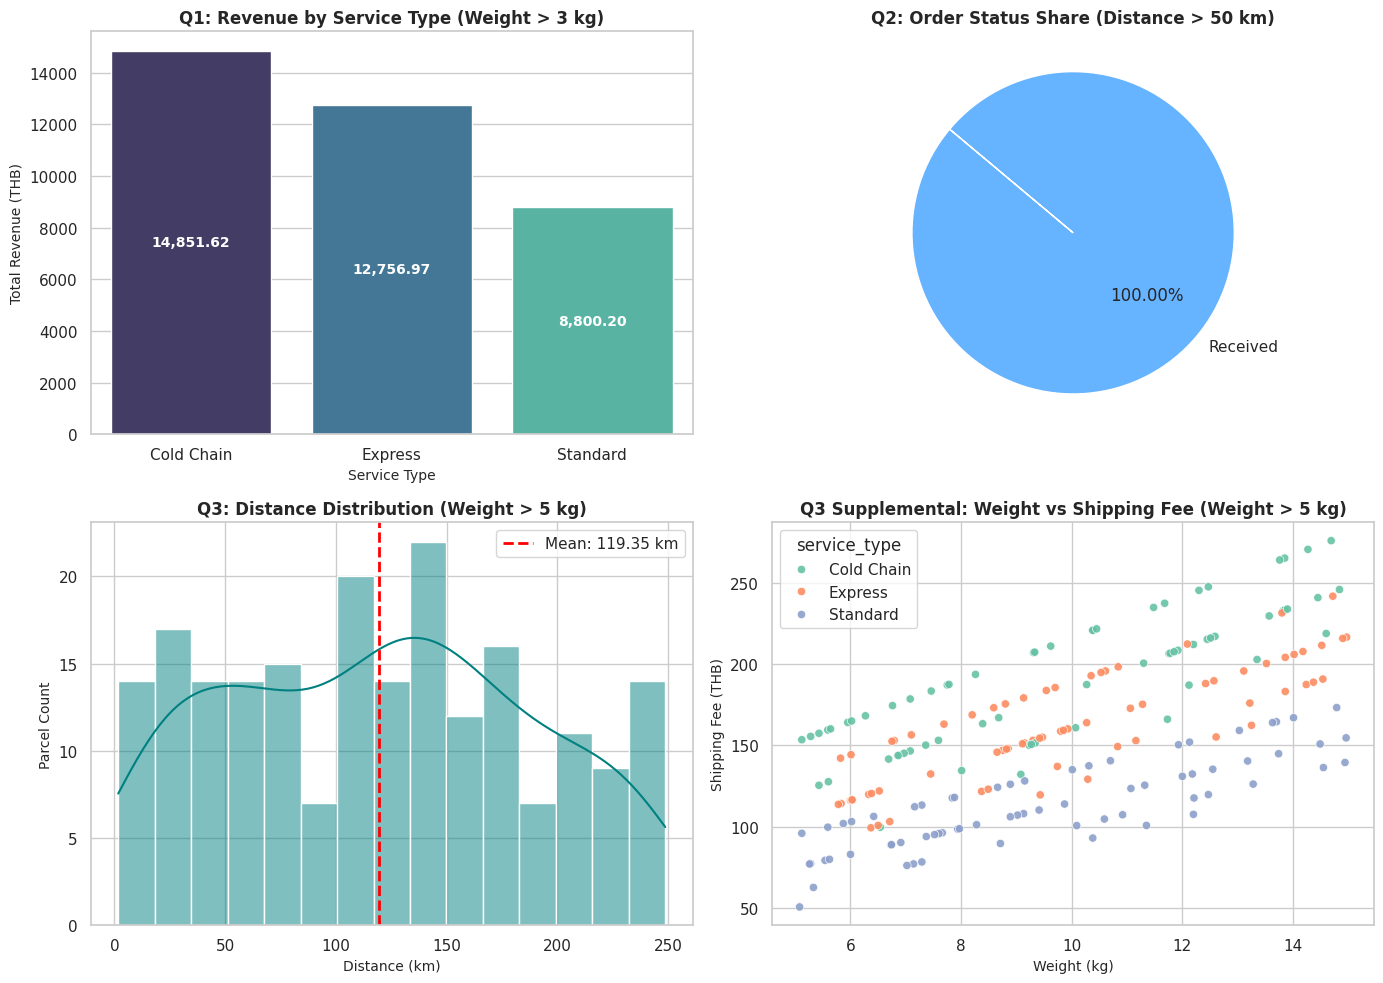

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ==========================================
# 1. กราฟคำตอบข้อ 1: รายได้รวมแยกตามบริการ (น้ำหนัก > 3 กก.)
# ==========================================
df_q1 = df_intake[df_intake["weight_kg"] > 3].groupby("service_type")["shipping_fee"].sum().reset_index()

# แปลงชื่อแสดงผลภาษาอังกฤษเพื่อป้องกันกล่องสี่เหลี่ยม
df_q1["service_display"] = df_q1["service_type"].replace({
    "ด่วนพิเศษ (Express)": "Express",
    "แช่เย็น (Cold Chain)": "Cold Chain",
    "ธรรมดา": "Standard"
})

sns.barplot(data=df_q1, x="service_display", y="shipping_fee", ax=axes[0, 0], palette="mako")
axes[0, 0].set_title("Q1: Revenue by Service Type (Weight > 3 kg)", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Service Type", fontsize=10)
axes[0, 0].set_ylabel("Total Revenue (THB)", fontsize=10)

# ใส่ตัวเลขรายได้กำกับบนเสากราฟ
for p in axes[0, 0].patches:
    height = p.get_height()
    if height > 0:
        axes[0, 0].annotate(f"{height:,.2f}",
                            (p.get_x() + p.get_width() / 2., height / 2),
                            ha="center", va="center", color="white", fontweight="bold", fontsize=10)

# ==========================================
# 2. กราฟคำตอบข้อ 2: สัดส่วนสถานะพัสดุ (ระยะทาง > 50 กม.)
# ==========================================
df_q2 = df_intake[df_intake["distance_km"] > 50]["status"].value_counts().reset_index()
df_q2.columns = ["status_type", "count"]

df_q2["status_display"] = df_q2["status_type"].replace({
    "ส่งสำเร็จ": "Delivered",
    "รับแล้ว": "Received",
    "กำลังส่ง": "In Transit"
})

axes[0, 1].pie(
    df_q2["count"],
    labels=df_q2["status_display"],
    autopct="%1.2f%%",
    startangle=140,
    colors=["#66b3ff", "#99ff99", "#ffcc99"]
)
axes[0, 1].set_title("Q2: Order Status Share (Distance > 50 km)", fontsize=12, fontweight="bold")

# ==========================================
# 3. กราฟคำตอบข้อ 3: การกระจายระยะทาง (น้ำหนัก > 5 กก.)
# ==========================================
df_q3 = df_intake[df_intake["weight_kg"] > 5]
avg_dist = df_q3["distance_km"].mean()

sns.histplot(data=df_q3, x="distance_km", bins=15, kde=True, ax=axes[1, 0], color="teal")
axes[1, 0].axvline(avg_dist, color="red", linestyle="--", linewidth=2, label=f"Mean: {avg_dist:.2f} km")
axes[1, 0].set_title("Q3: Distance Distribution (Weight > 5 kg)", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Distance (km)", fontsize=10)
axes[1, 0].set_ylabel("Parcel Count", fontsize=10)
axes[1, 0].legend()

# ==========================================
# 4. กราฟสัมพันธ์: น้ำหนักเทียบค่าจัดส่ง (น้ำหนัก > 5 กก.)
# ==========================================
sns.scatterplot(data=df_q3, x="weight_kg", y="shipping_fee", hue="service_type", ax=axes[1, 1], palette="Set2", alpha=0.9)
axes[1, 1].set_title("Q3 Supplemental: Weight vs Shipping Fee (Weight > 5 kg)", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Weight (kg)", fontsize=10)
axes[1, 1].set_ylabel("Shipping Fee (THB)", fontsize=10)

plt.tight_layout()
plt.savefig("final_correct_graphs.png", dpi=300)
plt.show()

## วิเคราะห์ข้อมูลโดยใช้ SQL

In [ ]:

#  คำสั่ง SQL คำถามทั้ง 3 ข้อ (ตรงตามเกณฑ์ SELECT, WHERE, GROUP BY, ORDER BY )

# Query 1: (SELECT, WHERE, GROUP BY, Aggregate SUM/COUNT, ORDER BY)
sql_q1 = """
SELECT
    service_type,
    COUNT(parcel_id) AS total_orders,
    ROUND(SUM(shipping_fee), 2) AS total_revenue
FROM parcels
WHERE weight_kg > 3.0
GROUP BY service_type
ORDER BY total_revenue DESC;
"""

# Query 2: (SELECT, WHERE, GROUP BY, Aggregate COUNT, ORDER BY)
sql_q2 = """
SELECT
    updated_status,
    COUNT(parcel_id) AS total_count,
    ROUND(COUNT(parcel_id) * 100.0 / (SELECT COUNT(*) FROM parcels WHERE distance_km > 50.0), 2) AS percentage
FROM parcels
WHERE distance_km > 50.0
GROUP BY updated_status
ORDER BY total_count DESC;
"""

# Query 3: (มี SELECT, WHERE, GROUP BY, Aggregate AVG/SUM/COUNT, ORDER BY)
sql_q3 = """
SELECT
    COUNT(parcel_id) AS total_items,
    ROUND(AVG(distance_km), 2) AS avg_distance_km,
    ROUND(SUM(shipping_fee), 2) AS total_revenue
FROM parcels
WHERE weight_kg > 5.0
ORDER BY total_revenue DESC;
"""


# 3. แสดงผลลัพธ์ด้วย pandas.read_sql_query() เป็น DataFrame

print("1. บริการจัดส่งประเภทไหนทำรายได้รวมสูงสุด และมีจำนวนออเดอร์เท่าไหร่?")
display(pd.read_sql_query(sql_q1, conn))

print("\n2. พัสดุแต่ละสถานะมีจำนวนกี่รายการ และคิดเป็นสัดส่วนกี่ % ของพัสดุทั้งหมด?")
display(pd.read_sql_query(sql_q2, conn))

print("\n3. พัสดุที่มีน้ำหนักเกิน 5 กก. มีระยะทางจัดส่งเฉลี่ยกี่กิโลเมตร และสร้างรายได้รวมเท่าไหร่?")
display(pd.read_sql_query(sql_q3, conn))


1. บริการจัดส่งประเภทไหนทำรายได้รวมสูงสุด และมีจำนวนออเดอร์เท่าไหร่?


,service_type,total_orders,total_revenue
0,ด่วนพิเศษ (Express),98,35981.50
1,แช่เย็น (Cold Chain),76,26888.25
2,ธรรมดา,73,25860.35



2. พัสดุแต่ละสถานะมีจำนวนกี่รายการ และคิดเป็นสัดส่วนกี่ % ของพัสดุทั้งหมด?


,updated_status,total_count,percentage
0,ส่งสำเร็จ,91,34.47
1,รับแล้ว,87,32.95
2,กำลังส่ง,86,32.58



3. พัสดุที่มีน้ำหนักเกิน 5 กก. มีระยะทางจัดส่งเฉลี่ยกี่กิโลเมตร และสร้างรายได้รวมเท่าไหร่?


,total_items,avg_distance_km,total_revenue
0,213,154.4,78396.3
